## Import Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras._tf_keras.keras import layers
from keras._tf_keras.keras.models import Sequential
from keras._tf_keras.keras.layers import Dense,Flatten,Dropout,BatchNormalization
from keras._tf_keras.keras.losses import SparseCategoricalCrossentropy
from keras._tf_keras.keras.callbacks import EarlyStopping

## Set Constant Values

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = 224
CHANNELS = 3

## Download or load the dataset 

In [3]:
training = "datasets/Road pothole conv/train/"
testing = "datasets/Road pothole conv/test/"

## Image Preprocessing

### Create Dataset for train,test,validation

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  training,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMAGE_SIZE, IMAGE_SIZE),
  batch_size=BATCH_SIZE)

Found 675 files belonging to 2 classes.
Using 540 files for training.


In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
  testing,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(IMAGE_SIZE, IMAGE_SIZE),
  batch_size=BATCH_SIZE)

Found 16 files belonging to 2 classes.
Using 13 files for training.


In [6]:
val_ds = tf.keras.utils.image_dataset_from_directory(
  training,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(IMAGE_SIZE, IMAGE_SIZE),
  batch_size=BATCH_SIZE)

Found 675 files belonging to 2 classes.
Using 135 files for validation.


In [7]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

['Plain', 'Pothole']


## Visualize the data

In [8]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


## Configure the dataset for performance

In [9]:
trian_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

## Standardize the data

In [10]:
normalization_layer = layers.Rescaling(1./255)

In [11]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image))

0.0 1.0


## Resize and Rescale

In [12]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(0.1 / 256)
])

## Data Augmentation

In [13]:
data_augmentation  = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2)
])

In [14]:
train_ds = train_ds.map(
    lambda x,y: (data_augmentation(x, training=True),y),
).prefetch(buffer_size = tf.data.AUTOTUNE)

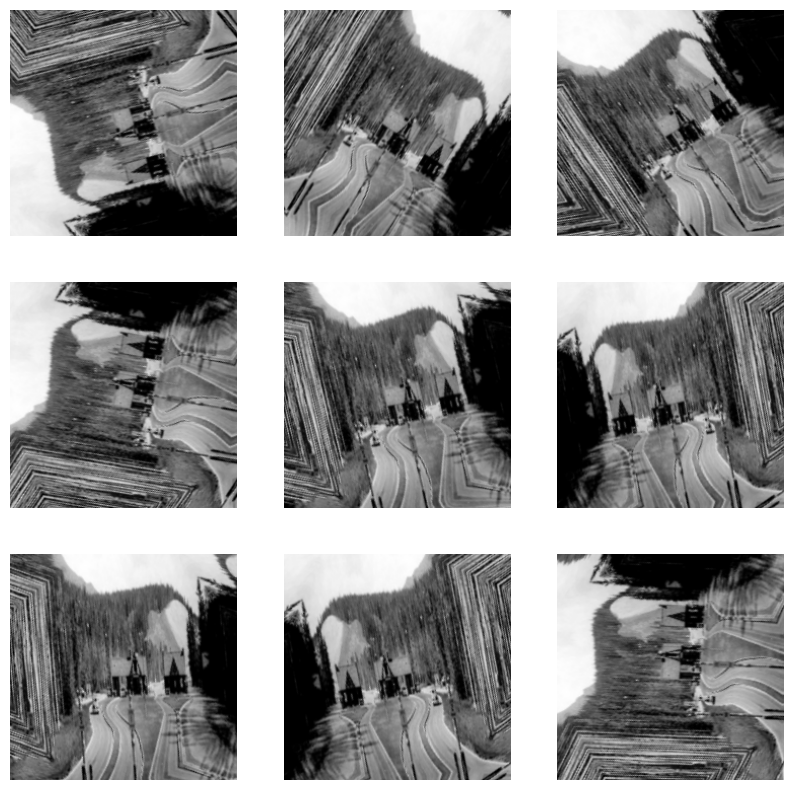

In [15]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

Define the EarlyStopping callback

In [16]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # or 'val_accuracy' depending on your goal
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,  # Restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# CNN Model Implementation

Model Layering

In [17]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes, activation='softmax')
])

Compile the model

In [18]:
model.compile(
    optimizer='adam',
    loss= "sparse_categorical_crossentropy",
    metrics=['accuracy']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,090 (12.62 MB)

 Trainable params: 3,309,090 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [19]:
epochs = 30
history = model.fit(
  train_ds,
  epochs=epochs, 
  validation_data=val_ds,
  batch_size=BATCH_SIZE
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 848ms/step - accuracy: 0.5550 - loss: 0.7559 - val_accuracy: 0.7704 - val_loss: 0.5049
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 562ms/step - accuracy: 0.7635 - loss: 0.4916 - val_accuracy: 0.8000 - val_loss: 0.4139
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 530ms/step - accuracy: 0.7999 - loss: 0.4595 - val_accuracy: 0.8370 - val_loss: 0.4257
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 547ms/step - accuracy: 0.8342 - loss: 0.4059 - val_accuracy: 0.7259 - val_loss: 0.6282
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 559ms/step - accuracy: 0.7129 - loss: 0.5777 - val_accuracy: 0.7926 - val_loss: 0.4549
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 547ms/step - accuracy: 0.8345 - loss: 0.3828 - val_accuracy: 0.7852 - val_loss: 0.6354
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 535ms/step - accuracy: 0.8402 - loss: 0.3944 - val_accuracy: 0.8296 - val_loss: 0.4065
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 534ms/step - accuracy: 0.8713 - loss: 0.3525 - val_accurac

Evaluate the model

In [20]:
model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6923 - loss: 0.5635


[0.5634512901306152, 0.692307710647583]

# Visualize training results

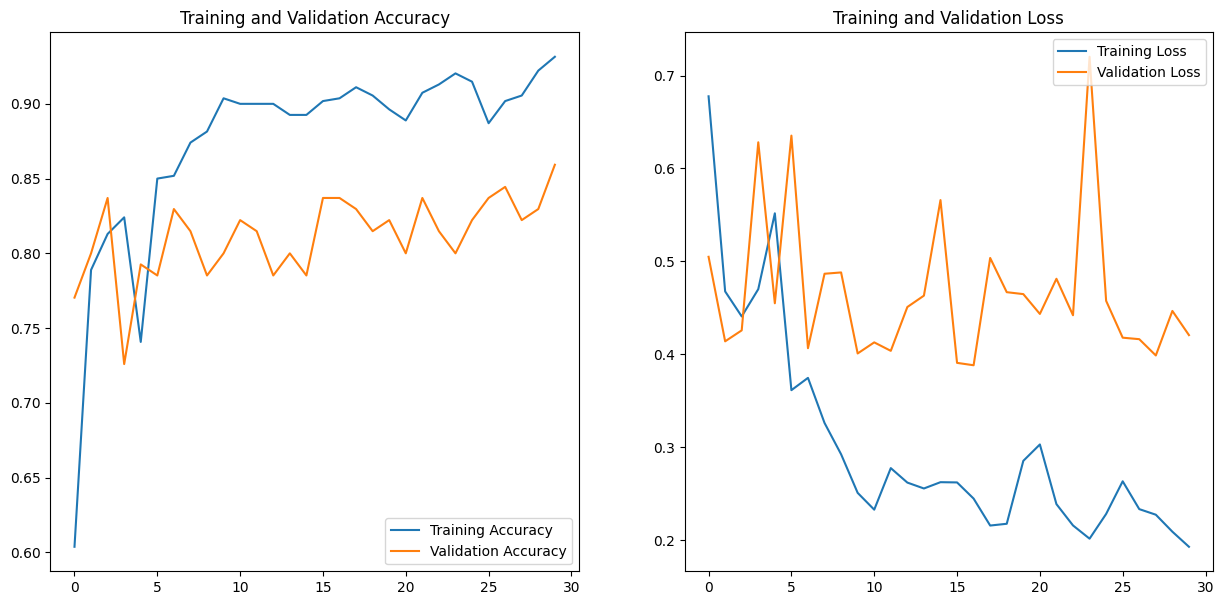

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Save the model

In [22]:
model.save('Model CNN.keras')

# MobileNet Model Implementation

In [23]:
from keras._tf_keras.keras.applications import MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [24]:
model_mobile = Sequential()
resize_and_rescale
model_mobile.add(base_model)
model_mobile.add(Flatten())
model_mobile.add(Dense(256,activation='relu'))
model_mobile.add(Dropout(0.5))
model_mobile.add(BatchNormalization())
model_mobile.add(Dense(num_classes,activation='sigmoid'))
model_mobile.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    16,056,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,316,098 (69.87 MB)

 Trainable params: 16,057,602 (61.25 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

In [25]:
model_mobile.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

Train the model

In [26]:
epochs = 10
history = model_mobile.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=early_stopping
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 23s 974ms/step - accuracy: 0.6898 - loss: 0.6747 - val_accuracy: 0.7481 - val_loss: 1.2984
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 854ms/step - accuracy: 0.8422 - loss: 0.4025 - val_accuracy: 0.7407 - val_loss: 1.0026
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 851ms/step - accuracy: 0.8130 - loss: 0.3945 - val_accuracy: 0.7704 - val_loss: 0.5946
Epoch 4/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 858ms/step - accuracy: 0.8592 - loss: 0.3097 - val_accuracy: 0.8222 - val_loss: 0.4199
Epoch 5/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 874ms/step - accuracy: 0.8758 - loss: 0.2915 - val_accuracy: 0.8222 - val_loss: 0.4027
Epoch 6/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 868ms/step - accuracy: 0.8864 - loss: 0.3136 - val_accuracy: 0.8000 - val_loss: 0.3492
Epoch 7/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 846ms/step - accuracy: 0.8622 - loss: 0.3495 - val_accuracy: 0.8000 - val_loss: 0.3605
Epoch 8/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 847ms/step - accuracy: 0.8860 - loss: 0.2884 - val_accu

Evaluate the model

In [27]:
model_mobile.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.8462 - loss: 0.3030


[0.30297553539276123, 0.8461538553237915]

Visualize training accuracy and loss

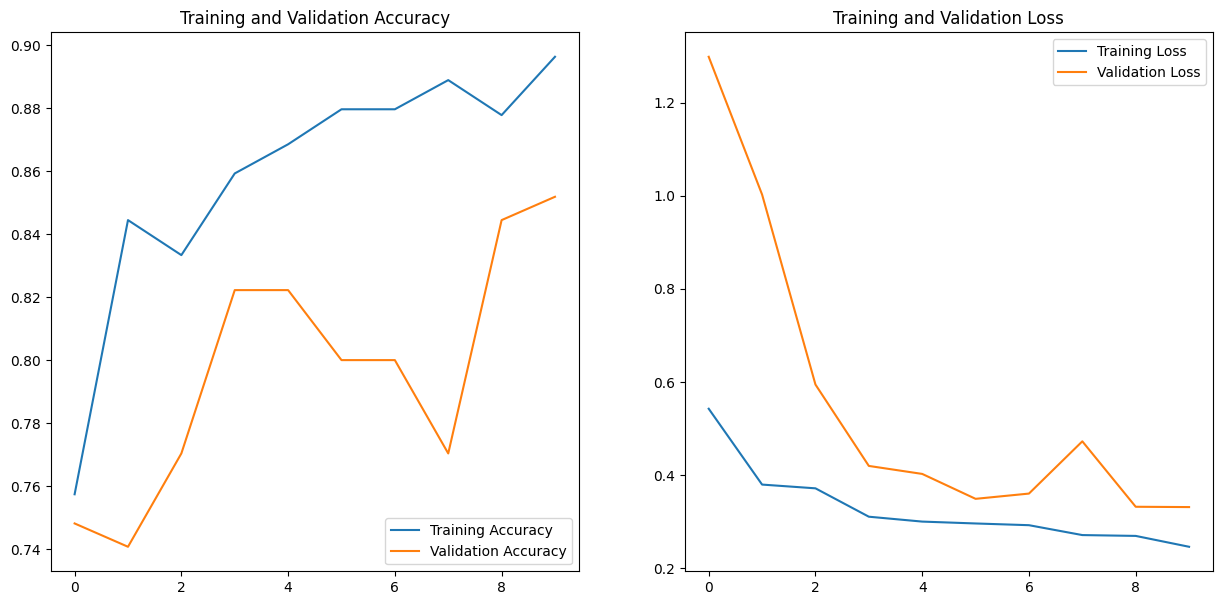

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Save the model

In [29]:
model_mobile.save('Model MobileNet.keras')

# InceptionResNet Model Implementation

In [30]:
from keras._tf_keras.keras.applications import InceptionResNetV2
base_model = InceptionResNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [31]:
model_inc = Sequential()
resize_and_rescale
model_inc.add(base_model)
model_inc.add(Flatten())
model_inc.add(Dense(256,activation='relu'))
model_inc.add(Dropout(0.5))
model_inc.add(BatchNormalization())
model_inc.add(Dense(num_classes,activation='sigmoid'))
model_inc.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_resnet_v2             │ (None, 5, 5, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 38400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     9,830,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_204         │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,168,930 (244.79 MB)

 Trainable params: 9,831,682 (37.50 MB)

 Non-trainable params: 54,337,248 (207.28 MB)

In [32]:
model_inc.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

Train the model

In [33]:
epochs = 10
history = model_inc.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=early_stopping
)

Epoch 1/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 107s 5s/step - accuracy: 0.4564 - loss: 0.9483 - val_accuracy: 0.5037 - val_loss: 1.4829
Epoch 2/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 87s 5s/step - accuracy: 0.5500 - loss: 0.7458 - val_accuracy: 0.5037 - val_loss: 1.1078
Epoch 3/10
17/17 ━━━━━━━━━━━━━━━━━━━━ 83s 5s/step - accuracy: 0.6328 - loss: 0.6626 - val_accuracy: 0.5037 - val_loss: 0.8387
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


Evaluate the model

In [34]:
model_inc.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5385 - loss: 1.3382


[1.3382446765899658, 0.5384615659713745]

Visualize training accuracy and losses

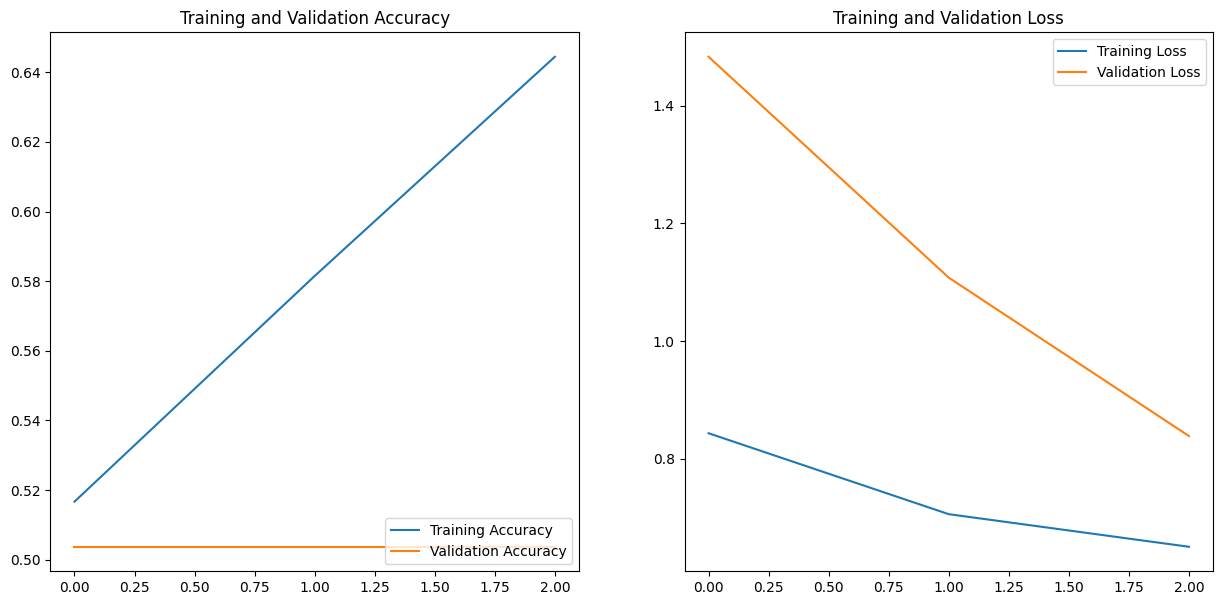

In [36]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']

val_loss = history.history['val_loss']

epochs_range = range(3)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Save the model

In [37]:
model_inc.save('Model InceptionResNet.keras')